In [1]:
import numpy as np

from copy import copy, deepcopy

from pycbc.types import TimeSeries, load_frequencyseries
from pycbc.psd import interpolate

from scipy.signal import windows
from scipy.interpolate import interp1d

import ldc.io.hdf5 as hdfio

from matplotlib import pyplot as plt
plt.style.use('../paper.mplstyle')

/home/gareth.cabourndavies/environments/env_lisa_premerger/lib/python3.10/site-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal


In [2]:
# This cell contains the information about inputs

input_data = '../datasets/LDC2_sangria_hm_training.hdf'
output_format = '{channel}_sangria_hm_PSD.txt'
segment_duration = 1576800

In [3]:
# Load in the sangria dataset

tdi_ts, tdi_descr = hdfio.load_array(input_data, name="obs/tdi")
X = tdi_ts['X']
Y = tdi_ts['Y']
Z = tdi_ts['Z']

In [4]:
# Convert to AET timeseries
A = (Z - X)/np.sqrt(2)
E = (X - 2*Y + Z)/np.sqrt(6)
T = (X + Y + Z)/np.sqrt(3)

A_ts = TimeSeries(A, delta_t=5.)
E_ts = TimeSeries(E, delta_t=5.)
T_ts = TimeSeries(T, delta_t=5.)

In [5]:
# Calculate the PSDs

A_psd = A_ts.psd(segment_duration)
E_psd = E_ts.psd(segment_duration)
T_psd = T_ts.psd(segment_duration)

A_psd = interpolate(A_psd, A_ts.delta_f)
E_psd = interpolate(E_psd, E_ts.delta_f)
T_psd = interpolate(T_psd, T_ts.delta_f)

No CuPy
No CuPy or GPU PhenomHM module.
No CuPy or GPU response available.
No CuPy or GPU interpolation available.


In [6]:
# Save to files for use in later analysis

# A_psd.save(output_format.format(channel='A'))
# E_psd.save(output_format.format(channel='E'))
# T_psd.save(output_format.format(channel='T'))

In [7]:
# We also want to plot the models that we used in the premerger paper
ae_model = load_frequencyseries('model_AE_TDI1_optimistic.txt')
ae_model = ae_model[:1000001]
ae_model = ae_model.astype(np.complex128)
t_model = load_frequencyseries('model_T_TDI1_optimistic.txt')


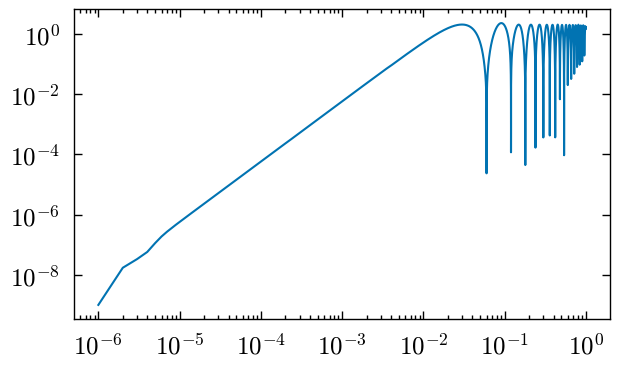

In [8]:
# Load the AE response function from the file used in the premerger paper
f = ae_model.sample_frequencies[:-100]
ae_raw = np.genfromtxt('../datasets/AE_response_function.txt')
plt.loglog(f, ae_raw)

In [9]:
# From Babak, Petiteau and Hewitson, 2021
# Constants
A = 1.14e-44
alpha = 1.8
f2 = 0.31
a1 = -0.25
b1 = -2.7
ak = -0.27
bk = -2.47

def f1fk(tobs):
    f1 = (a1 * np.log10(tobs) + b1) ** 10
    fk = (ak * np.log10(tobs) + bk) ** 10
    return f1, fk

def sgal(fm, tobs):
    f1, fk = f1fk(tobs)
    return 0.5 * A * fm ** (-7/3) * np.exp(-1 * (fm / f1) * alpha) * (1 + np.tanh(- (fm - fk) / (f2)))

def wd_background(tobs):
    fm = f * 1000
    wd_cs = sgal(fm, tobs)
    return wd_cs * ae_raw ** 2

tb_labels = ['6 months', '1 year', '2 years', '4 years']
wd_backgrounds_bph = {
    tbl: wd_background(tby)
    for tbl, tby in zip(
        tb_labels,
        [0.5, 1, 2, 4]
    )
}

print("wd_backgrounds_bph", wd_backgrounds_bph)

tb_linestyles = {
    tbl: ls for tbl, ls in zip(tb_labels, ['-','--', '-.', ':'])
}
# for lbl, wdb in wd_backgrounds.items():
#     plt.semilogy(f, wdb, label=lbl, linestyle=tb_linestyles[lbl], c='k')


wd_backgrounds_bph {'6 months': <pycbc.types.array.Array object at 0x7fca66d5ee30>, '1 year': <pycbc.types.array.Array object at 0x7fcaa55fcb50>, '2 years': <pycbc.types.array.Array object at 0x7fca768bef20>, '4 years': <pycbc.types.array.Array object at 0x7fca6bdd6800>}


/home/gareth.cabourndavies/environments/env_lisa_premerger/lib/python3.10/site-packages/pycbc/types/array.py:435: RuntimeWarning: divide by zero encountered in power
  return self._data ** other


In [10]:
# From Robson, Cornish and Liu, 2019
A = 9e-45

# Choose one of these:
fit_params_6mo = (0.133, 243, 482, 917, 0.00258)
fit_params_1yr = (0.171, 292, 1020, 1680, 0.00215)
fit_params_2yr = (0.165, 299, 611, 1340, 0.00173)
fit_params_4yr = (0.138, -221, 521, 1680, 0.00113)

def wd_background(fit_params):
    alpha, beta, kappa, gamma, fk = fit_params

    # This is in characteristic strain
    wd_cs = A * f ** (-7/3) * np.exp(-f * alpha + beta * f * np.sin(kappa * f)) * (1 + np.tanh(gamma * (fk - f)))

    return wd_cs * ae_raw ** 2


tb_labels = ['6 months', '1 year', '2 years', '4 years']
wd_backgrounds_rcl = {
    tb: wd_background(fp)
    for tb, fp in zip(
        tb_labels,
        [fit_params_6mo, fit_params_1yr, fit_params_2yr, fit_params_4yr]
    )
}

print("wd_backgrounds_rcl", wd_backgrounds_rcl)

# tb_linestyles = {
#     tbl: ls for tbl, ls in zip(tb_labels, ['-','--', '-.', ':'])
# }

wd_backgrounds_rcl {'6 months': <pycbc.types.array.Array object at 0x7fcaa4e90820>, '1 year': <pycbc.types.array.Array object at 0x7fca6bdd6410>, '2 years': <pycbc.types.array.Array object at 0x7fca6bdd74f0>, '4 years': <pycbc.types.array.Array object at 0x7fca6bdd7580>}


/home/gareth.cabourndavies/environments/env_lisa_premerger/lib/python3.10/site-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/gareth.cabourndavies/environments/env_lisa_premerger/lib/python3.10/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


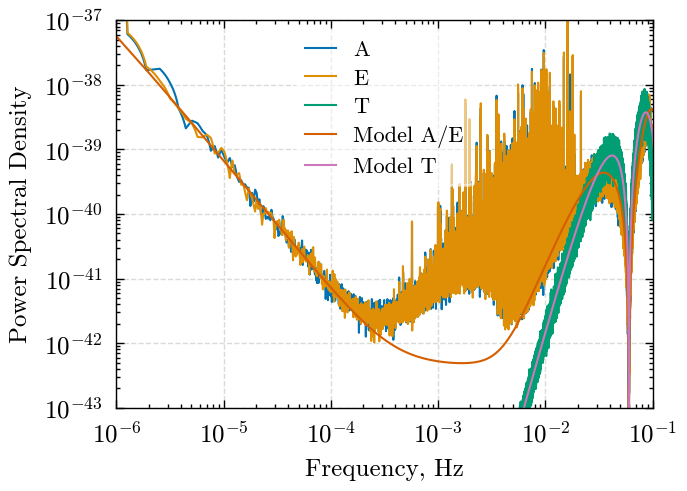

In [11]:
cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

width = plt.rcParams["figure.figsize"][0]
height = plt.rcParams["figure.figsize"][1] * 1.25
fig, ax = plt.subplots(1, figsize=(width, height))
ax.loglog(A_psd.sample_frequencies, A_psd, c=cycle[0], label='A')
ax.loglog(E_psd.sample_frequencies, E_psd, c=cycle[1], label='E')
ax.loglog(T_psd.sample_frequencies, T_psd, c=cycle[2], label='T')
ax.loglog(ae_model.sample_frequencies, ae_model, c=cycle[3], label='Model A/E')
ax.loglog(t_model.sample_frequencies, t_model, c=cycle[4], label='Model T')

ax.set_ylabel("Power Spectral Density")
ax.set_xlabel("Frequency, Hz")
leg1 = ax.legend(loc='upper center')
# line2 = []
# labels2 = []
# for tb, wdb in wd_backgrounds_bph.items():
#     line2.append(ax.loglog(f, wdb, c='k', linestyle=tb_linestyles[tb])[0])
#     labels2.append(tb)
# for tb, wdb in wd_backgrounds_rcl.items():
#     line2.append(ax.loglog(f, wdb, c='b', linestyle=tb_linestyles[tb])[0])
#     labels2.append(tb)
# ax.legend(line2, labels2, loc="upper center", title="Unresolved galactic foreground")
# ax.add_artist(leg1)
ax.set_ylim([1e-43, 1e-37])
ax.set_xlim([1e-6, 1e-1])
ax.grid(zorder=-100)

Now lets have a look at where the massive black hole binaries sit on this PSD plot

In [12]:
# Load in the mbhb-only dataset

tdi_ts, tdi_descr = hdfio.load_array(input_data, name="sky/mbhb/tdi")
X_mbhb = tdi_ts['X']
Y_mbhb = tdi_ts['Y']
Z_mbhb = tdi_ts['Z']

# Convert to AET timeseries
A_mbhb = (Z_mbhb - X_mbhb)/np.sqrt(2)
E_mbhb = (X_mbhb - 2*Y_mbhb + Z_mbhb)/np.sqrt(6)

A_mbhb_ts = TimeSeries(A_mbhb, delta_t=5.)
E_mbhb_ts = TimeSeries(E_mbhb, delta_t=5.)

/home/gareth.cabourndavies/environments/env_lisa_premerger/lib/python3.10/site-packages/IPython/core/events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/home/gareth.cabourndavies/environments/env_lisa_premerger/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


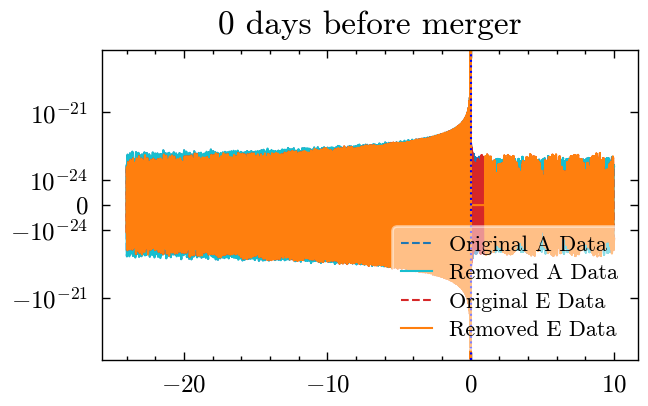

Error in callback <function flush_figures at 0x7fca76939090> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

In [ ]:
mbhbs, _ = hdfio.load_array(input_data, name="sky/mbhb/cat")

times_before = [0, 0.5, 1, 4, 7, 14]
mbhb_A_removed_psds = {}
mbhb_E_removed_psds = {}
mbhb_A_ts_removed = {}
mbhb_E_ts_removed = {}

mbhb_A_ts_removed[None] = A_mbhb_ts
mbhb_E_ts_removed[None] = E_mbhb_ts

mbhb_A_psd_None = A_mbhb_ts.psd(segment_duration)
mbhb_A_removed_psds[None] = interpolate(mbhb_A_psd_None, A_ts.delta_f)
mbhb_E_psd_None = A_mbhb_ts.psd(segment_duration)
mbhb_E_removed_psds[None] = interpolate(mbhb_E_psd_None, A_ts.delta_f)

for time_before in times_before:

    mbhb_A_t_removed = deepcopy(A_mbhb_ts)
    mbhb_E_t_removed = deepcopy(E_mbhb_ts)
    for i, mbhb in enumerate(mbhbs[:1]):
        # Remove up to 1 day after coalescence: so includes ringdown
        time_end = mbhb['CoalescenceTime'] + 86400 * 1
        time_end_idx = min(
            int(time_end / mbhb_A_t_removed.delta_t),
            len(mbhb_A_t_removed)
        )
        # Remove the time before merger
        time_start = mbhb['CoalescenceTime'] - time_before * 86400
        time_start_idx = max(
            int(time_start / mbhb_A_t_removed.delta_t),
            0
        )
        print(mbhb['CoalescenceTime'])
        print(
            time_start - mbhb['CoalescenceTime'],
            time_start_idx,
            time_end - mbhb['CoalescenceTime'],
            time_end_idx
        )
        # Overwrite the cut time with zeros:
        mbhb_A_t_removed.data[time_start_idx:time_end_idx] = 0
        mbhb_E_t_removed.data[time_start_idx:time_end_idx] = 0

        # cut the series for plotting, so that it doesnt take forever
        plot_start = mbhb['CoalescenceTime'] - 24 * 86400
        plot_start_idx = max(
            int(plot_start / mbhb_A_t_removed.delta_t),
            0
        )
        plot_end = mbhb['CoalescenceTime'] + 86400 * 10
        plot_end_idx = min(
            int(plot_end / mbhb_A_t_removed.delta_t),
            len(mbhb_A_t_removed)
        )
        fig, ax = plt.subplots()
        ax.plot(
            (A_mbhb_ts[plot_start_idx:plot_end_idx].sample_times - mbhb['CoalescenceTime']) / 86400,
            A_mbhb_ts[plot_start_idx:plot_end_idx],
            c='tab:blue', linestyle='--',
            label='Original A Data'
        )
        ax.plot(
            (mbhb_A_t_removed[plot_start_idx:plot_end_idx].sample_times - mbhb['CoalescenceTime']) / 86400,
            mbhb_A_t_removed[plot_start_idx:plot_end_idx],
            c='tab:cyan',
            label='Removed A Data'
        )
        # ax.plot(
        #     (E_mbhb_ts[plot_start_idx:plot_end_idx].sample_times - mbhb['CoalescenceTime']) / 86400,
        #     E_mbhb_ts[plot_start_idx:plot_end_idx],
        #     c='tab:red', linestyle='--',
        #     label='Original E Data'
        # )
        # ax.plot(
        #     (mbhb_E_t_removed[plot_start_idx:plot_end_idx].sample_times - mbhb['CoalescenceTime']) / 86400,
        #     mbhb_E_t_removed[plot_start_idx:plot_end_idx],
        #     c='tab:orange',
        #     label='Removed E Data'
        # )
        ax.axvline(-time_before, c='k', linestyle=':')
        ax.set_yscale('symlog', linthresh=1e-24)
        ax.set_title(f'{time_before} days before merger')
        ax.legend()
        
        fig.show()
    
    mbhb_A_ts_removed[time_before] = mbhb_A_t_removed
    mbhb_E_ts_removed[time_before] = mbhb_E_t_removed

    mbhb_A_psd = mbhb_A_ts_removed[time_before].psd(segment_duration)
    mbhb_A_removed_psds[time_before] = interpolate(mbhb_A_psd, A_ts.delta_f)
    mbhb_E_psd = mbhb_E_ts_removed[time_before].psd(segment_duration)
    mbhb_E_removed_psds[time_before] = interpolate(mbhb_E_psd, E_ts.delta_f)

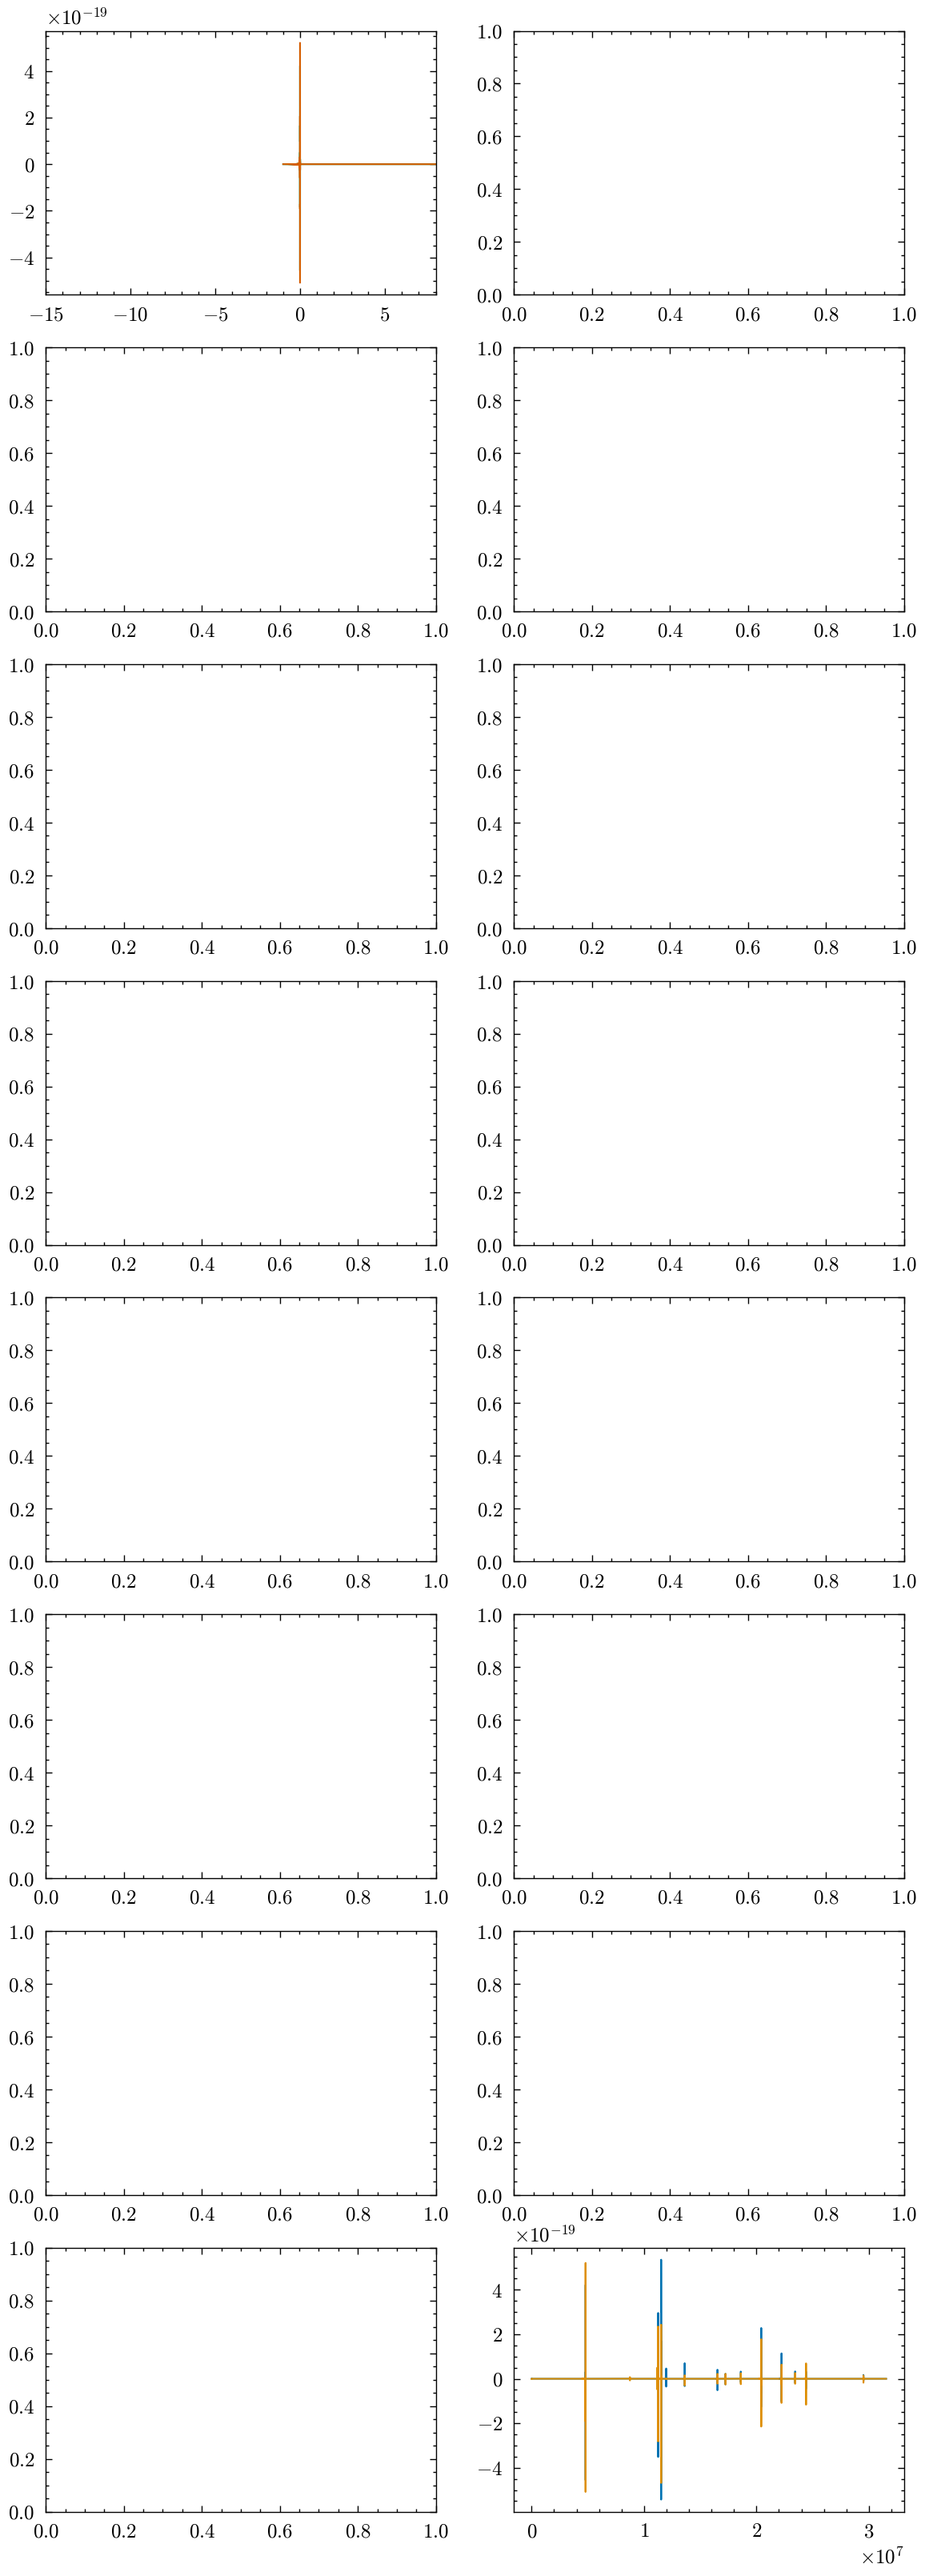

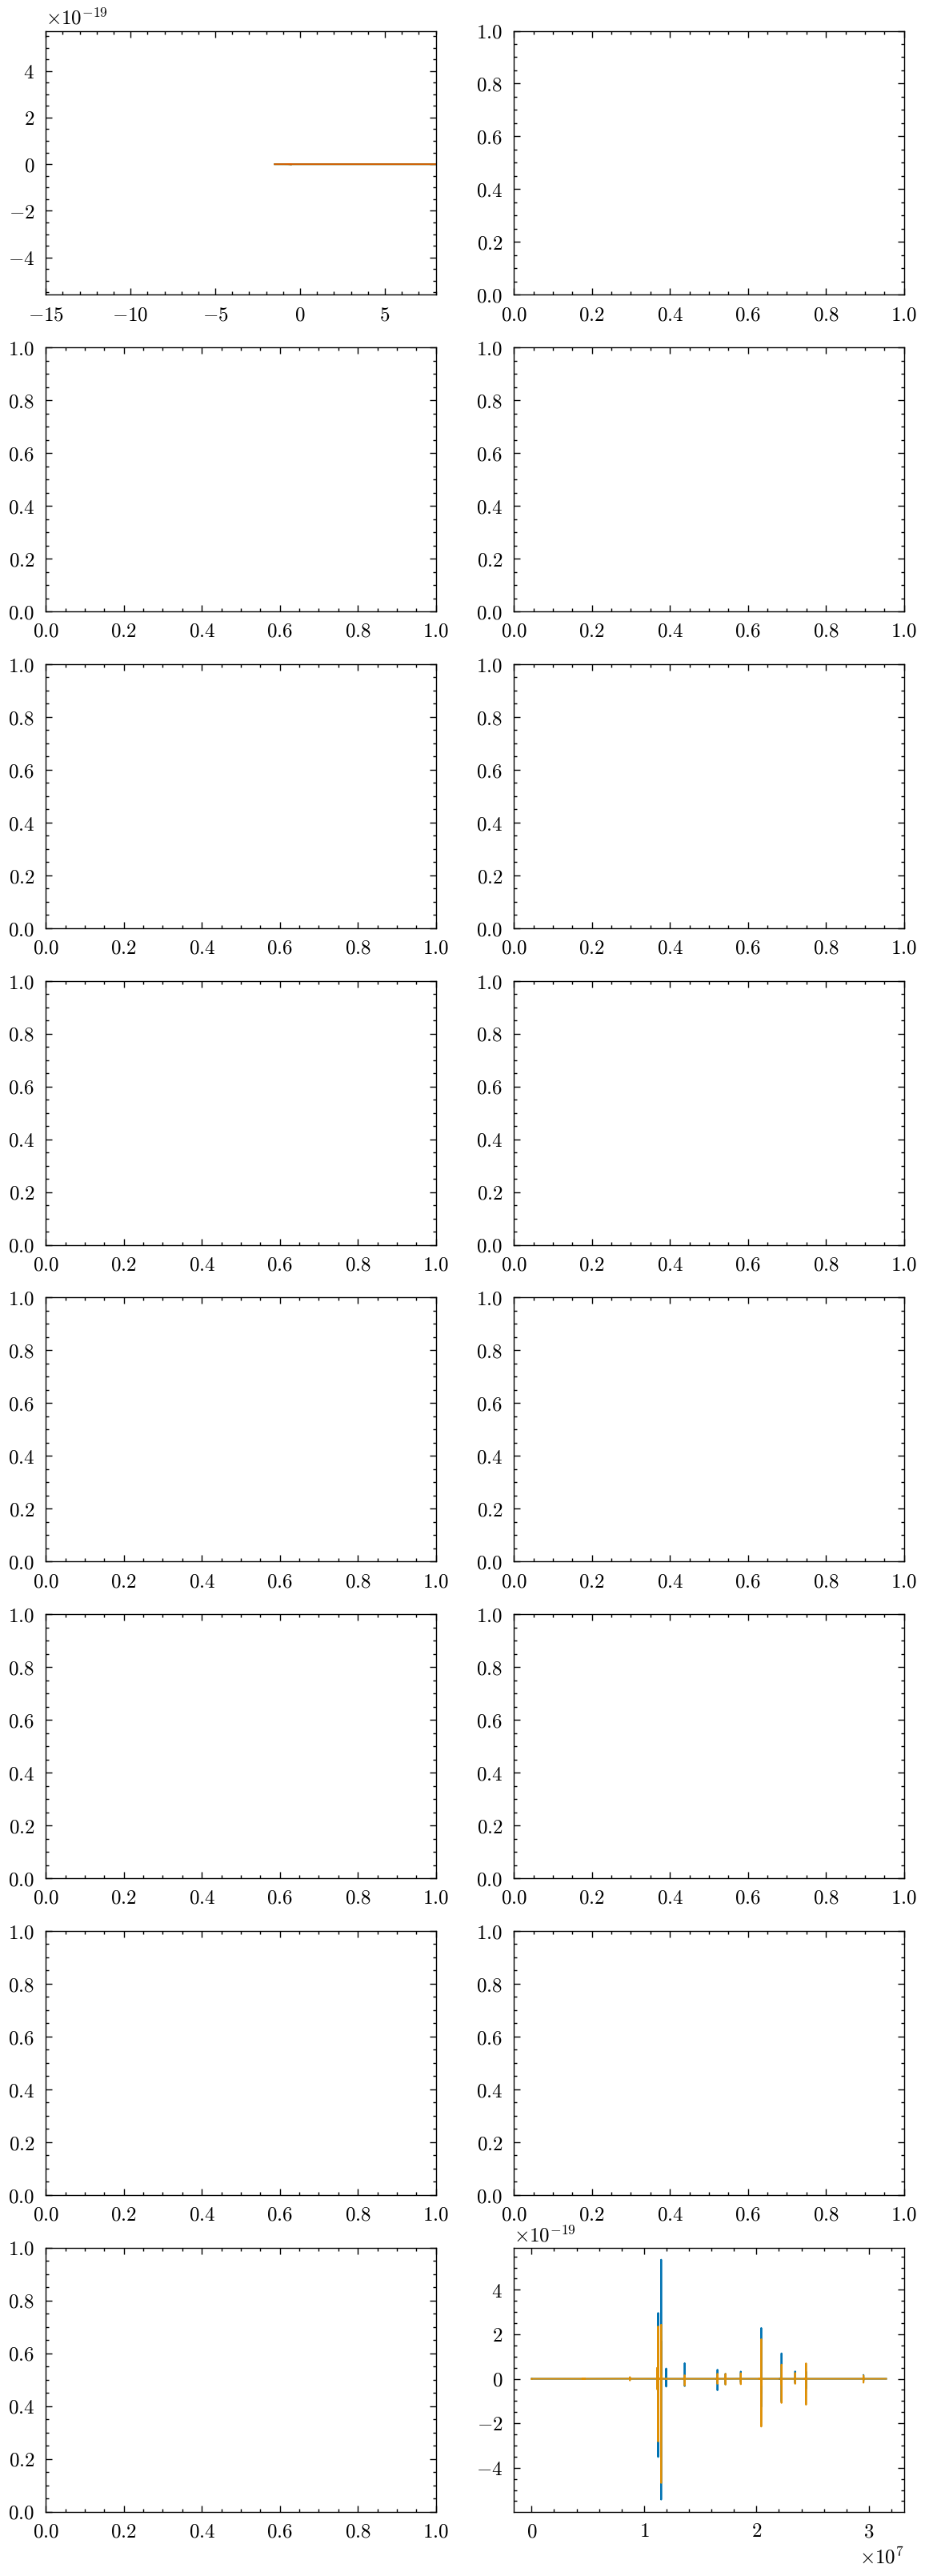

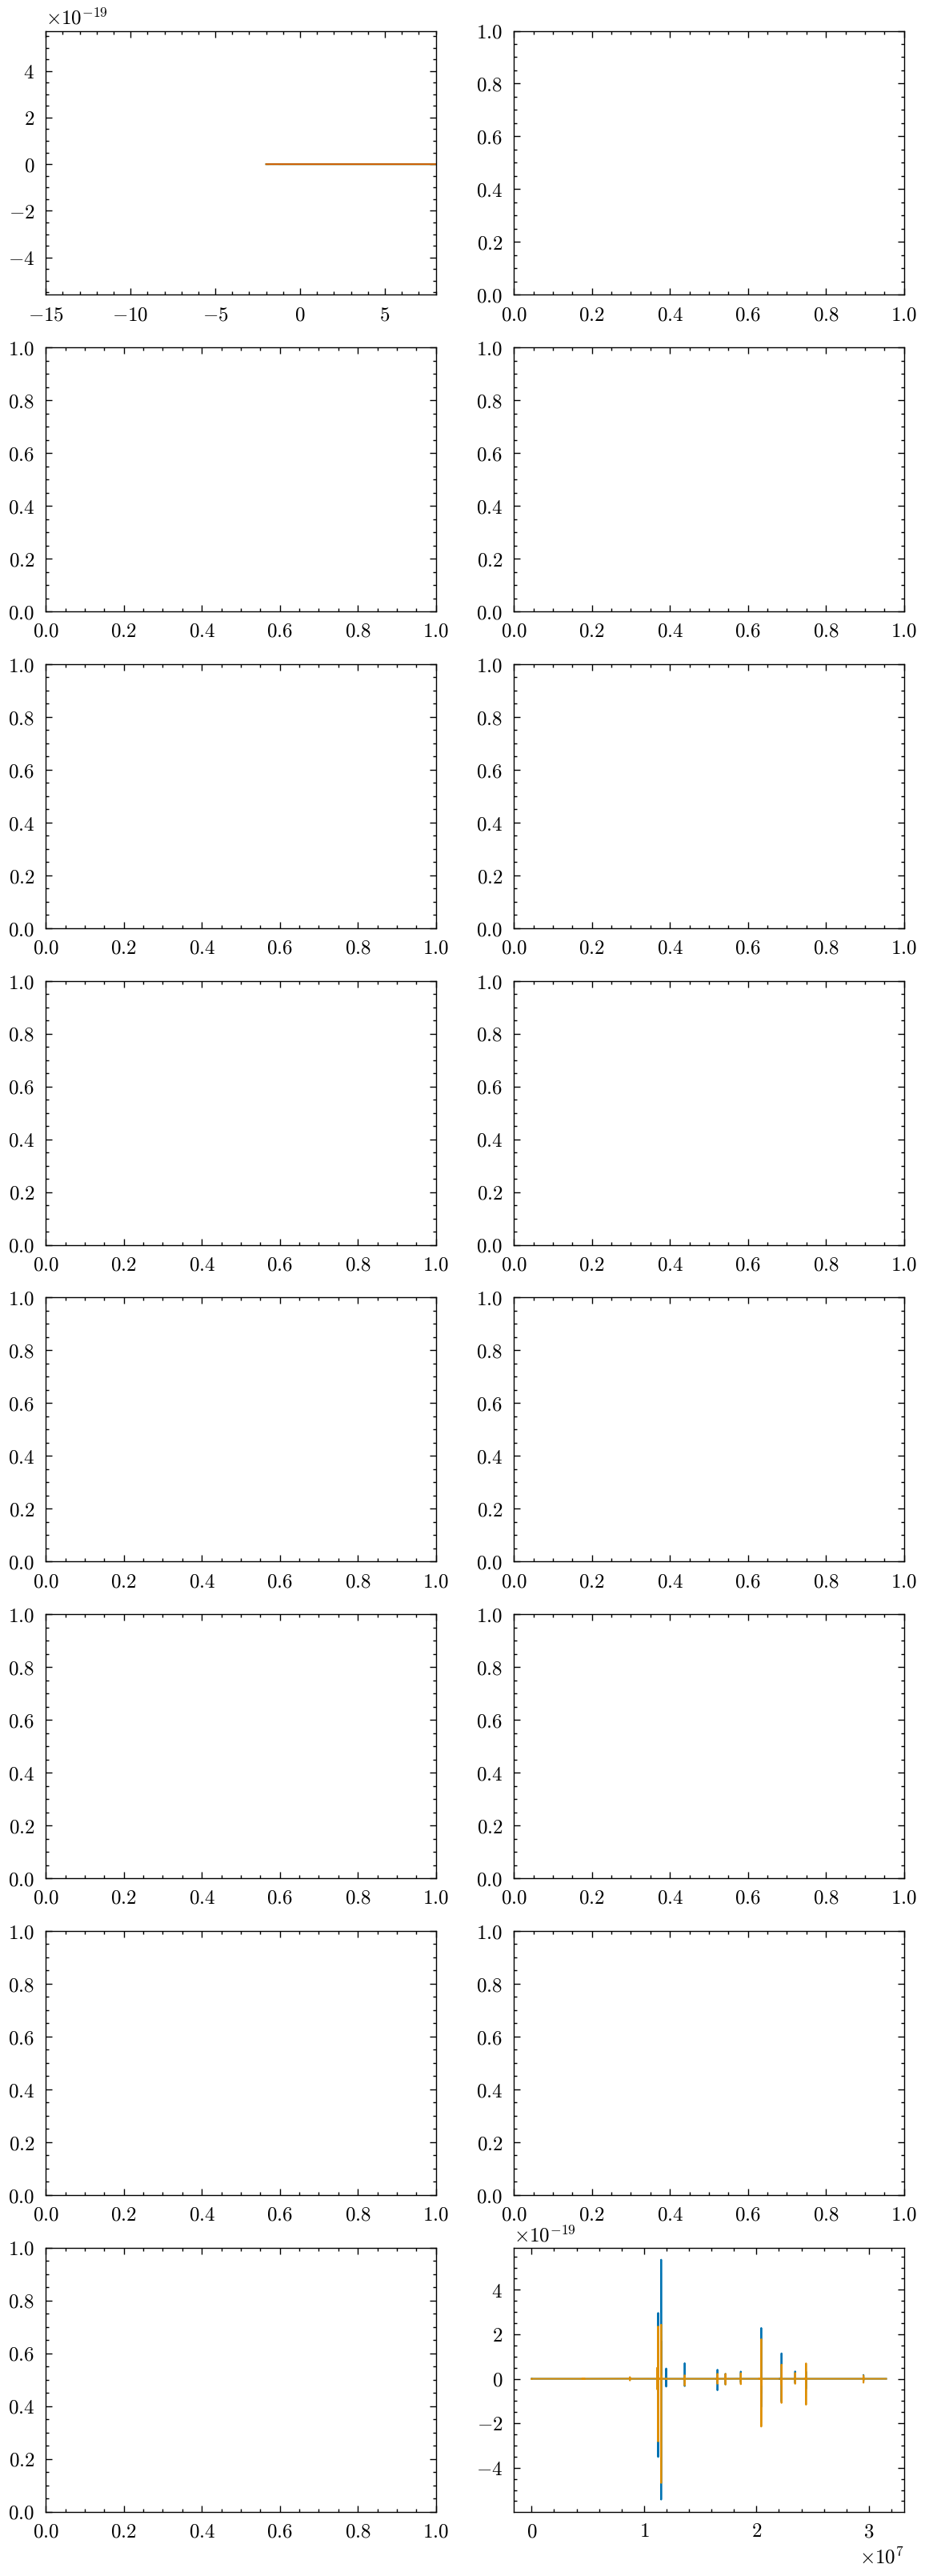

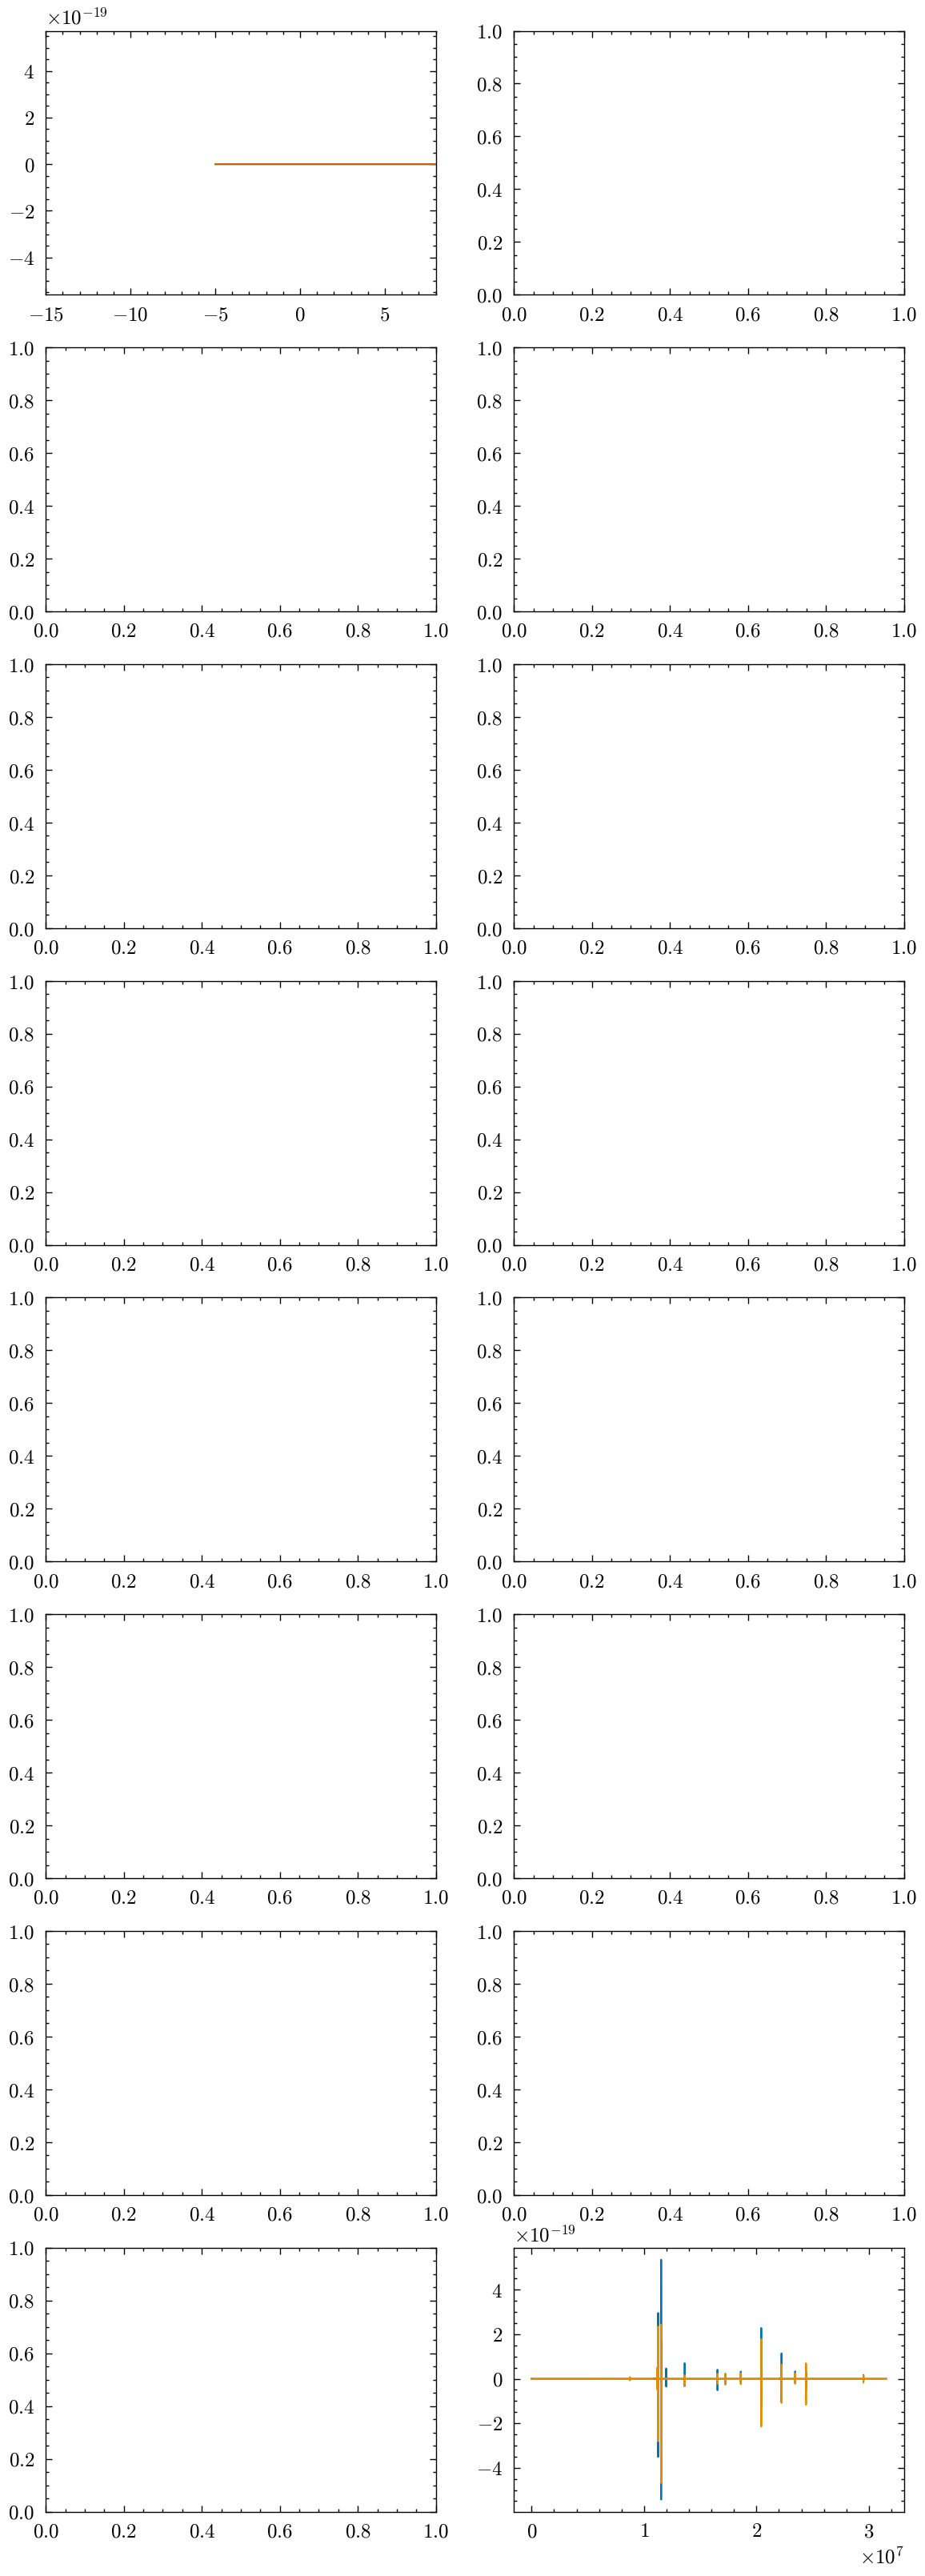

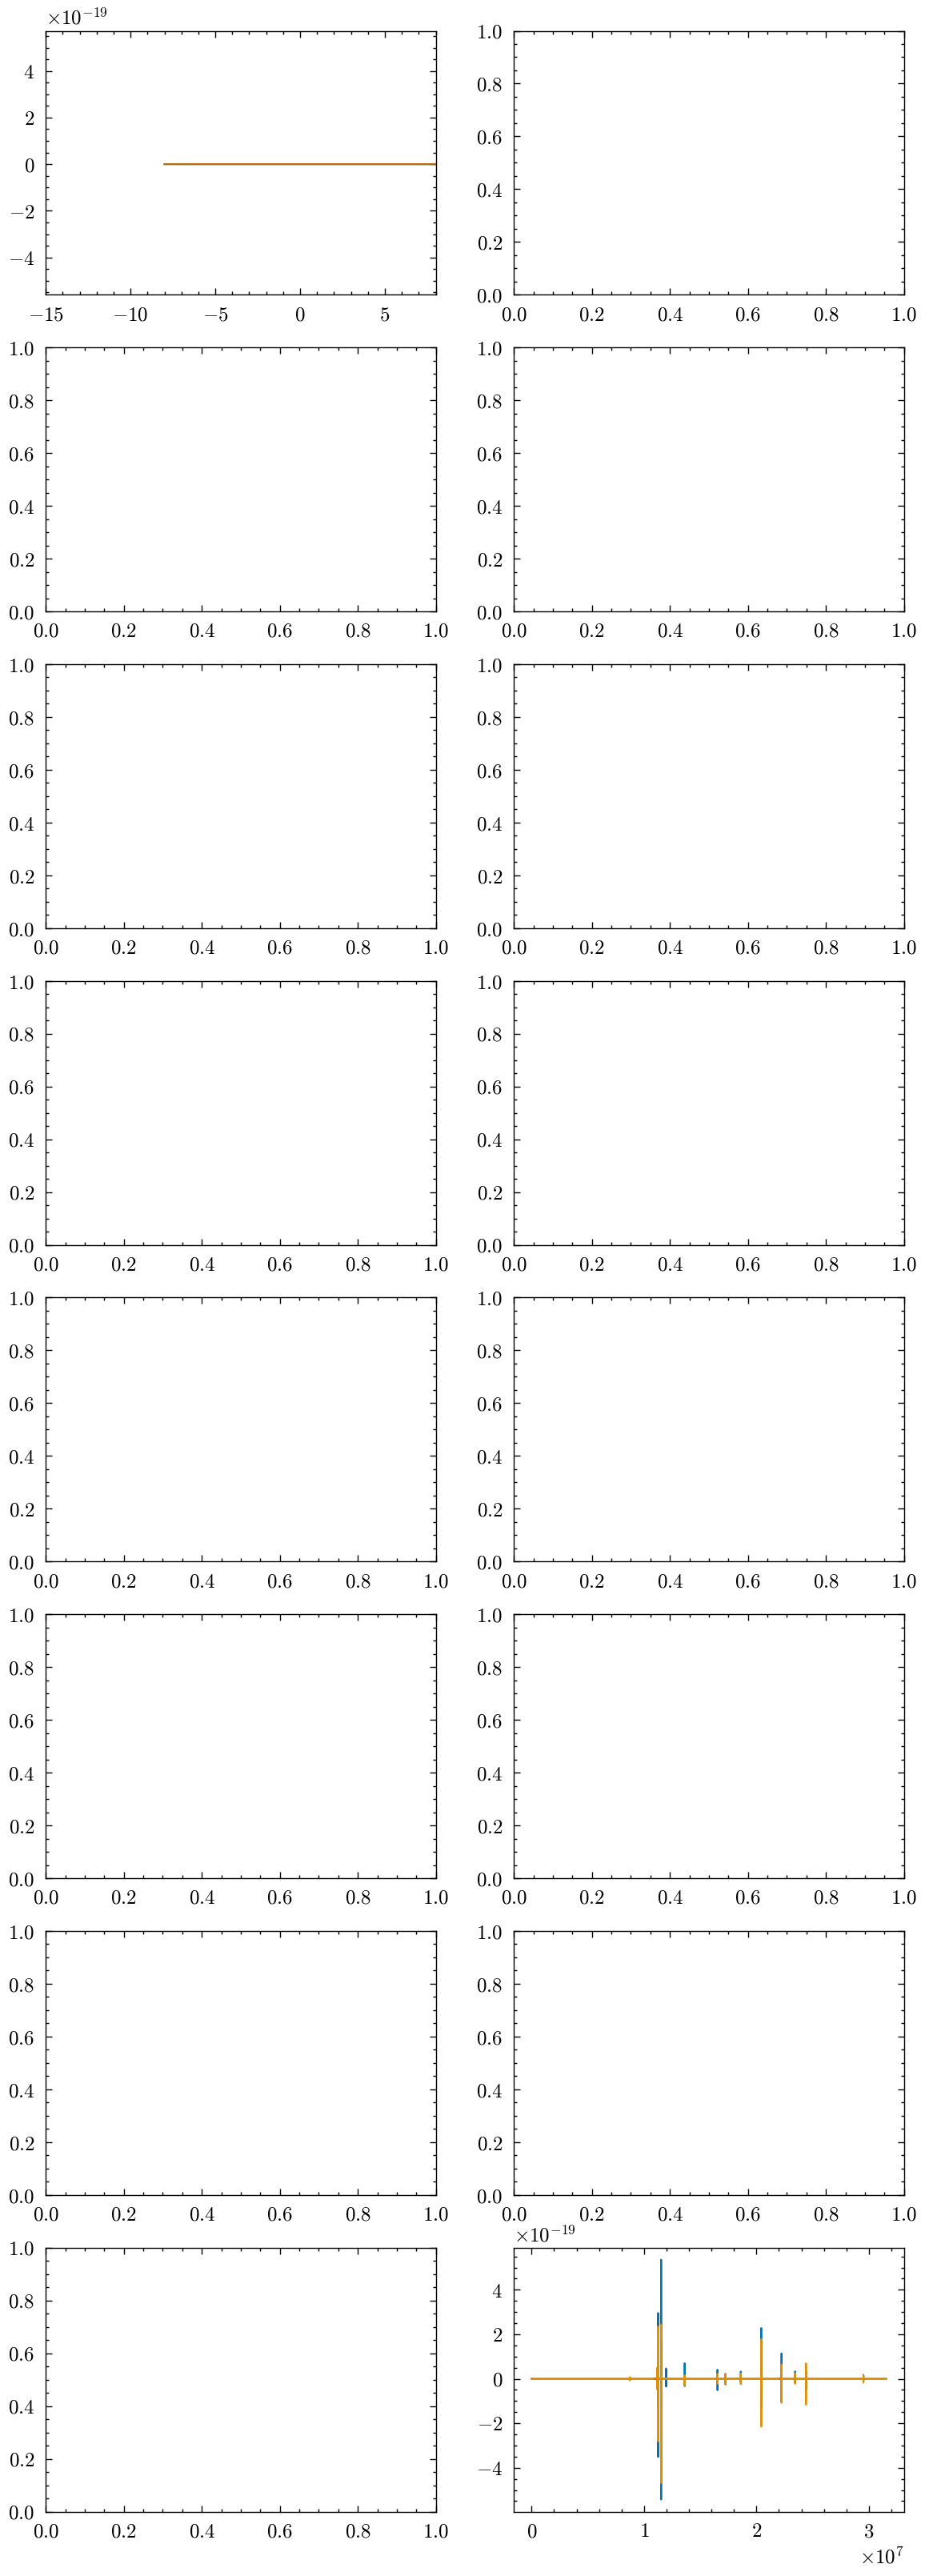

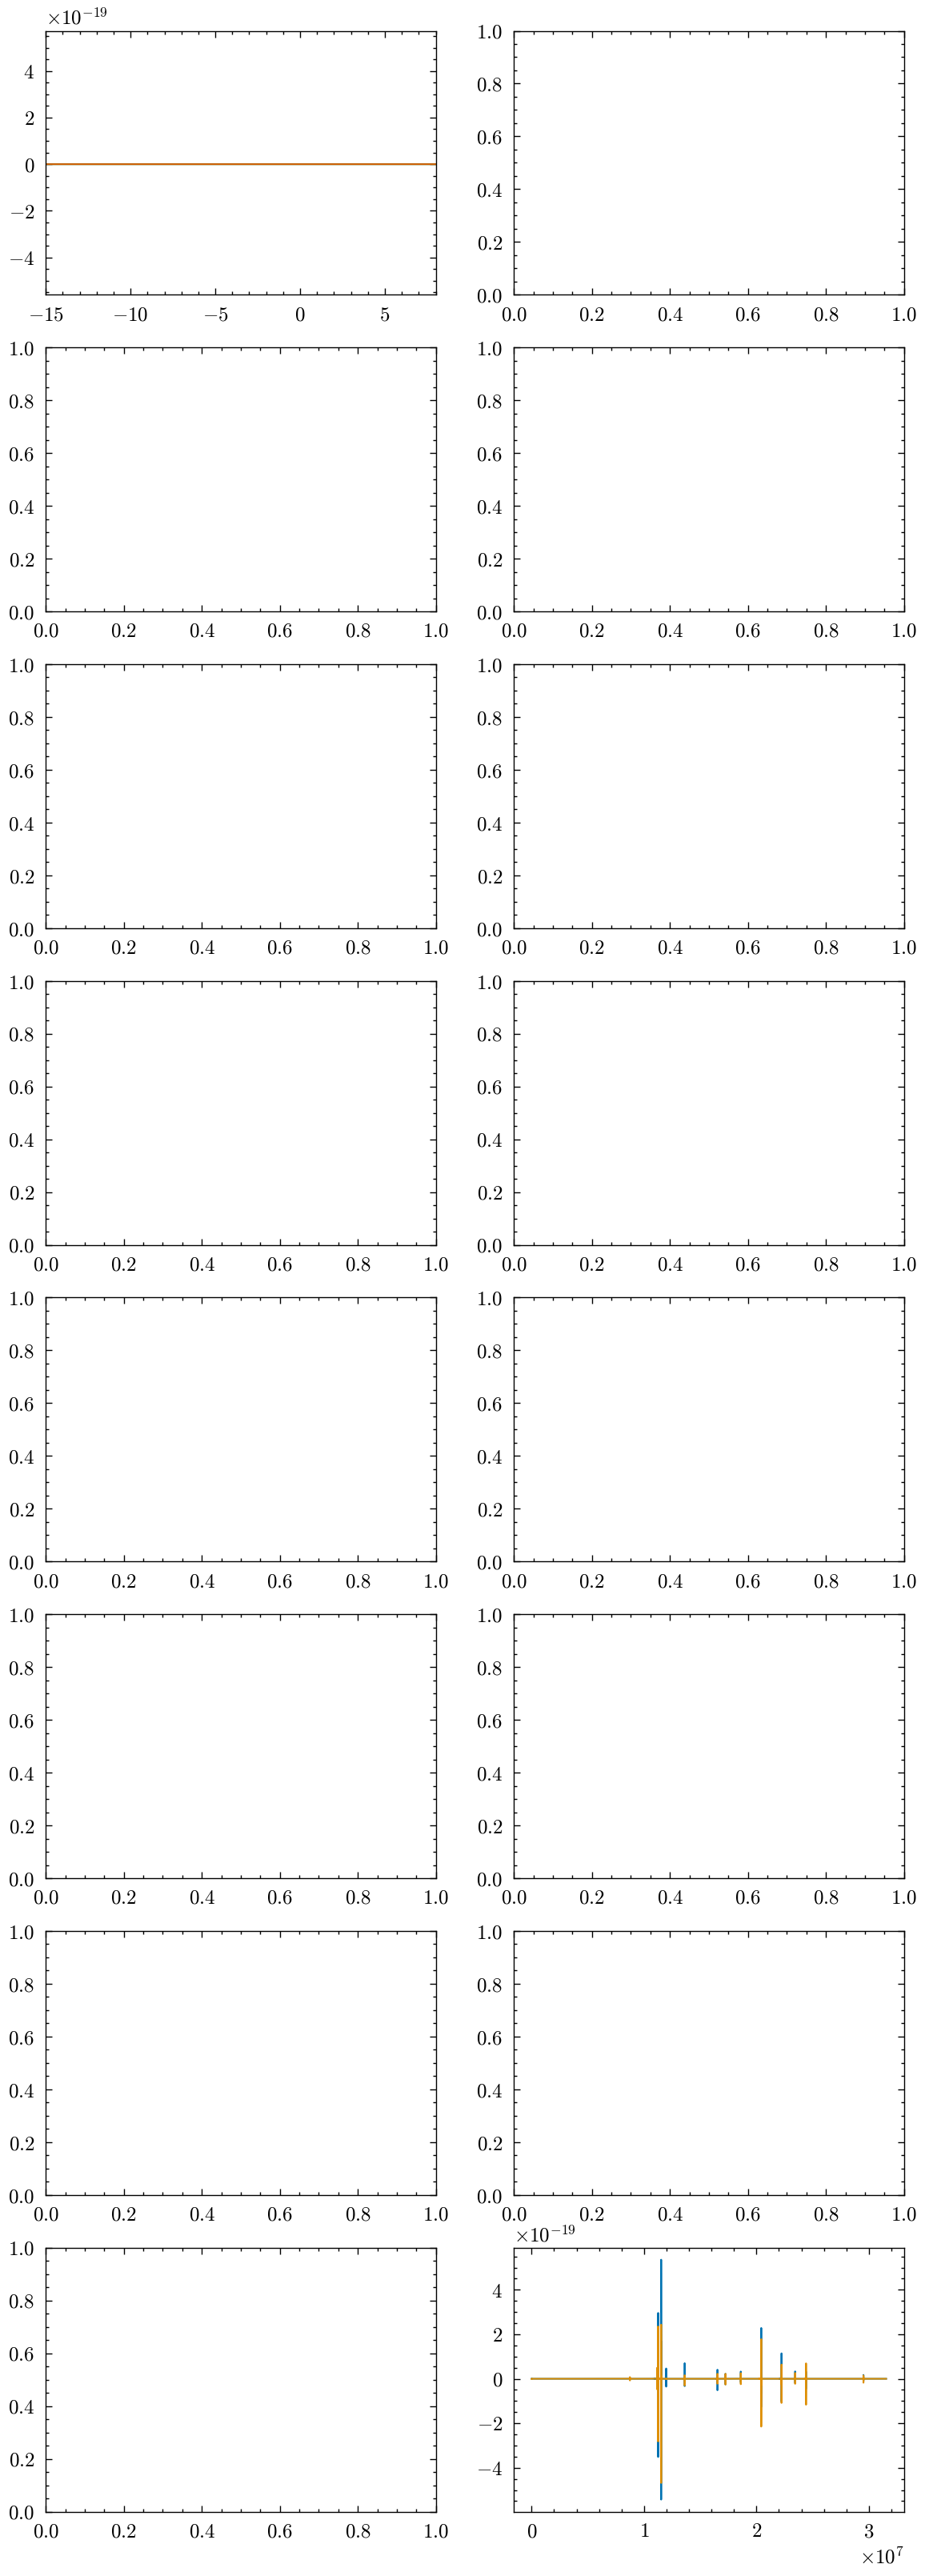

In [ ]:
for time_before in times_before:
    fig, axes = plt.subplots(8, 2, figsize=(width*2, height*8))
    axes[7,1].plot(
        mbhb_A_ts_removed[time_before].sample_times,
        mbhb_A_ts_removed[time_before]
    )
    axes[7,1].plot(
        mbhb_E_ts_removed[time_before].sample_times,
        mbhb_E_ts_removed[time_before]
    )
    for i, mbhb in enumerate(mbhbs[:1]):
        time_end = mbhb['CoalescenceTime'] + 86400 * 8
        time_end_idx = min(
            int(time_end / mbhb_A_ts_removed[time_before].delta_t),
            len(mbhb_A_ts_removed[time_before])
        )
        time_start = mbhb['CoalescenceTime'] - (time_before + 1) * 86400
        time_start_idx = max(
            int(time_start / mbhb_A_ts_removed[time_before].delta_t),
            0
        )
        axes[i // 2, i % 2].plot(
            A_mbhb_ts[time_start_idx:time_end_idx].sample_times,
            A_mbhb_ts[time_start_idx:time_end_idx],
            linestyle='--',
            alpha=0.5
        )
        axes[i // 2, i % 2].plot(
            E_mbhb_ts[time_start_idx:time_end_idx].sample_times,
            E_mbhb_ts[time_start_idx:time_end_idx],
            linestyle='--',
            alpha=0.5
        )
        axes[i // 2, i % 2].plot(
            (mbhb_A_ts_removed[time_before][time_start_idx:time_end_idx].sample_times - mbhb['CoalescenceTime']) / 86400,
            mbhb_A_ts_removed[time_before][time_start_idx:time_end_idx]
        )
        axes[i // 2, i % 2].plot(
            (mbhb_E_ts_removed[time_before][time_start_idx:time_end_idx].sample_times - mbhb['CoalescenceTime']) / 86400,
            mbhb_E_ts_removed[time_before][time_start_idx:time_end_idx]
        )
        axes[i // 2, i % 2].set_xlim(
            [-15, 8]
        )

    fig.show()

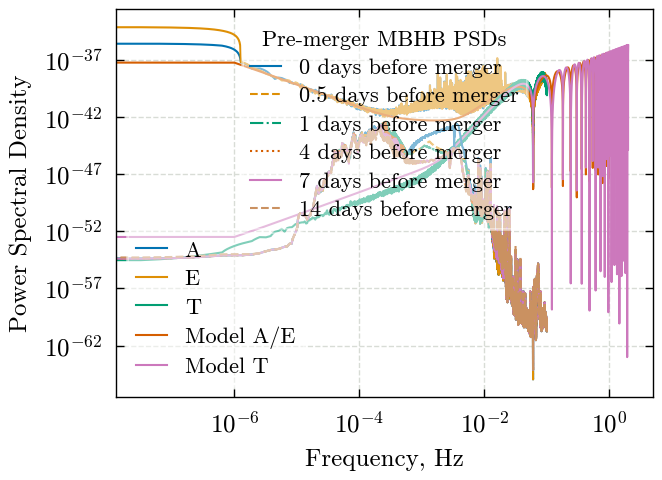

In [ ]:
psd_linestyles = {
    tb: (ls, col) for tb, ls, col in zip(
        times_before,
        ['-','--', '-.', ':', '-', '--'],
        plt.rcParams['axes.prop_cycle'].by_key()['color']
    )
}

width = plt.rcParams["figure.figsize"][0]
height = plt.rcParams["figure.figsize"][1] * 1.25
fig, ax = plt.subplots(1, figsize=(width, height))
ax.loglog(A_psd.sample_frequencies, A_psd, c=cycle[0], label='A')
ax.loglog(E_psd.sample_frequencies, E_psd, c=cycle[1], label='E')
ax.loglog(T_psd.sample_frequencies, T_psd, c=cycle[2], label='T')
ax.loglog(ae_model.sample_frequencies, ae_model, c=cycle[3], label='Model A/E')
ax.loglog(t_model.sample_frequencies, t_model, c=cycle[4], label='Model T')

ax.set_ylabel("Power Spectral Density")
ax.set_xlabel("Frequency, Hz")
leg1 = ax.legend(loc='lower left')
line2 = []
labels2 = []
for k, psd in mbhb_A_removed_psds.items():
    line2.append(ax.loglog(
        psd.sample_frequencies,
        psd,
        c=psd_linestyles[k][1],
        linestyle=psd_linestyles[k][0]
    )[0])
    labels2.append(f'{k} days before merger')
ax.legend(line2, labels2, loc="upper center", title="Pre-merger MBHB PSDs")
ax.add_artist(leg1)
# ax.set_ylim([1e-43, 1e-37])
# ax.set_xlim([1e-6, 1e-1])
ax.grid(zorder=-100)